# MicroProyecto: Clasificación de Tumores Cerebrales con CNNs

## Dataset: Brain Tumor MRI Scans — Versión PyTorch

Este notebook implementa una red neuronal convolucional (CNN) con **PyTorch** para clasificar imágenes de resonancias magnéticas (MRI) de tumores cerebrales en 4 categorías:
- **Glioma**: tumor cerebral maligno
- **Healthy**: cerebro sano (control)
- **Meningioma**: tumor generalmente benigno
- **Pituitary**: tumor en la glándula pituitaria

Dataset fuente: Kaggle Brain Tumor MRI Dataset

## 1. Importación de Librerías y Configuración

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import os

# Establecer semillas para reproducibilidad
torch.manual_seed(42)
np.random.seed(42)

# Seleccionar dispositivo (GPU si está disponible)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')

print(f"PyTorch version: {torch.__version__}")
print(f"Dispositivo de cómputo: {DEVICE}")

PyTorch version: 2.11.0+cu130
Dispositivo de cómputo: cpu


## 2. Definición de Parámetros y Rutas del Dataset

In [2]:
# Ruta al dataset
DATA_DIR = 'MRI Scans'

# Parámetros de configuración
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.15  # 15% para validación
TEST_SPLIT = 0.15        # 15% para test

# Clases del dataset (tumores cerebrales)
CLASSES = ['glioma', 'healthy', 'meningioma', 'pituitary']
NUM_CLASSES = len(CLASSES)

print(f"Configuración del dataset:")
print(f"  - Directorio: {DATA_DIR}")
print(f"  - Tamaño de imagen: {IMG_SIZE}")
print(f"  - Batch size: {BATCH_SIZE}")
print(f"  - Split: Train 70% / Val 15% / Test 15%")
print(f"  - Número de clases: {NUM_CLASSES}")
print(f"  - Clases: {CLASSES}")

Configuración del dataset:
  - Directorio: MRI Scans
  - Tamaño de imagen: (128, 128)
  - Batch size: 32
  - Split: Train 70% / Val 15% / Test 15%
  - Número de clases: 4
  - Clases: ['glioma', 'healthy', 'meningioma', 'pituitary']


## 3. Carga del Dataset

Usaremos `torchvision.datasets.ImageFolder` para cargar las imágenes organizadas por carpetas de clase.
Luego `random_split` divide en train/val/test, y `DataLoader` genera los batches.

Las transformaciones aplicadas son:
- Redimensionamiento a 128x128
- Conversión a tensor
- Normalización de píxeles al rango [0, 1] (los tensores de `ToTensor` ya están en [0,1])

In [3]:
def load_brain_tumor_dataset(data_dir, img_size, batch_size, val_split, test_split, seed=42):
    """
    Carga el dataset de tumores cerebrales desde directorios organizados por clase.
    Crea tres conjuntos: entrenamiento (70%), validación (15%) y prueba (15%).

    Parámetros:
    - data_dir: directorio raíz con subcarpetas por clase
    - img_size: tupla (height, width) para redimensionar las imágenes
    - batch_size: tamaño del lote para entrenamiento
    - val_split: fracción de datos para validación (0.0-1.0)
    - test_split: fracción de datos para prueba (0.0-1.0)
    - seed: semilla para reproducibilidad

    Retorna:
    - train_loader, val_loader, test_loader: DataLoaders
    - class_names: lista de nombres de clases
    """

    transform = transforms.Compose([
        transforms.Resize(img_size),
        transforms.ToTensor(),  # Convierte a [C, H, W] y escala a [0, 1]
    ])

    # Cargar dataset completo con ImageFolder
    full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)
    class_names = full_dataset.classes
    total = len(full_dataset)

    # Calcular tamaños de cada split
    n_test = int(total * test_split)
    n_val = int(total * val_split)
    n_train = total - n_val - n_test

    generator = torch.Generator().manual_seed(seed)
    train_ds, val_ds, test_ds = random_split(full_dataset, [n_train, n_val, n_test], generator=generator)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=0, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

    print(f"Dataset cargado exitosamente")
    print(f"  Clases encontradas: {class_names}")
    print(f"  Total de imágenes : {total}")
    print(f"  Train: {n_train} imágenes ({n_train/total*100:.1f}%) | {len(train_loader)} batches")
    print(f"  Val  : {n_val}   imágenes ({n_val/total*100:.1f}%) | {len(val_loader)} batches")
    print(f"  Test : {n_test}  imágenes ({n_test/total*100:.1f}%) | {len(test_loader)} batches")

    return train_loader, val_loader, test_loader, class_names

In [4]:
train_loader, val_loader, test_loader, class_names = load_brain_tumor_dataset(
    DATA_DIR, IMG_SIZE, BATCH_SIZE, VALIDATION_SPLIT, TEST_SPLIT
)

Dataset cargado exitosamente
  Clases encontradas: ['glioma', 'healthy', 'meningioma', 'pituitary']
  Total de imágenes : 7023
  Train: 4917 imágenes (70.0%) | 154 batches
  Val  : 1053   imágenes (15.0%) | 33 batches
  Test : 1053  imágenes (15.0%) | 33 batches


## 4. Análisis del Dataset

In [5]:
def analyze_dataset(train_loader, val_loader, test_loader, class_names):
    """
    Muestra información estadística y estructura del dataset.
    """
    print("=" * 60)
    print("ANÁLISIS DEL DATASET - BRAIN TUMOR MRI")
    print("=" * 60)

    print(f"\nClases del dataset:")
    for i, name in enumerate(class_names):
        print(f"   {i}: {name}")

    # Verificar forma de un batch
    images, labels = next(iter(train_loader))
    print(f"\nForma de los datos:")
    print(f"   Batch de imágenes : {tuple(images.shape)} -> [batch, C, H, W]")
    print(f"   Batch de etiquetas: {tuple(labels.shape)} (índices de clase)")
    print(f"   Tamaño de imagen  : {images.shape[2]}x{images.shape[3]} px, {images.shape[1]} canales")

    print(f"\nVerificación de normalización:")
    print(f"   Valor mínimo: {images.min().item():.4f}")
    print(f"   Valor máximo: {images.max().item():.4f}")
    print(f"   Rango correcto: [0, 1]" if images.max() <= 1.0 else "   Advertencia: valores fuera de rango")
    print("\n" + "=" * 60)

analyze_dataset(train_loader, val_loader, test_loader, class_names)

ANÁLISIS DEL DATASET - BRAIN TUMOR MRI

Clases del dataset:
   0: glioma
   1: healthy
   2: meningioma
   3: pituitary

Forma de los datos:
   Batch de imágenes : (32, 3, 128, 128) -> [batch, C, H, W]
   Batch de etiquetas: (32,) (índices de clase)
   Tamaño de imagen  : 128x128 px, 3 canales

Verificación de normalización:
   Valor mínimo: 0.0000
   Valor máximo: 1.0000
   Rango correcto: [0, 1]



/Users/I508111/miniconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


## 5. Visualización de Ejemplos del Dataset

Ejemplos de imágenes del conjunto de entrenamiento:


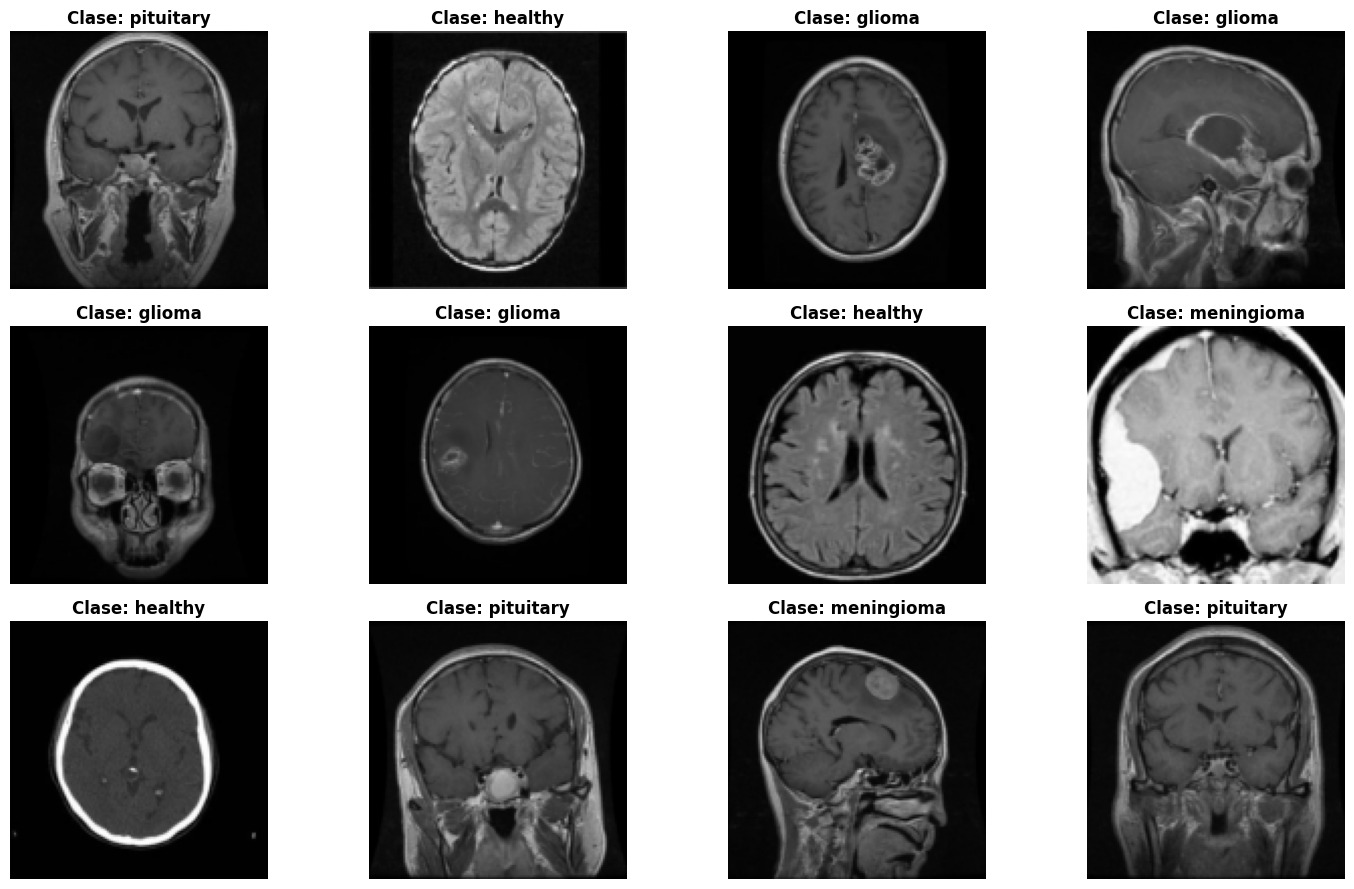

Visualización completada: 12 imágenes mostradas


In [6]:
def visualize_samples(loader, class_names, num_samples=12):
    """
    Visualiza ejemplos del dataset en un grid.

    Parámetros:
    - loader: DataLoader del cual tomar las imágenes
    - class_names: lista con los nombres de las clases
    - num_samples: número de imágenes a visualizar (múltiplo de 4)
    """
    cols = 4
    rows = num_samples // cols

    images, labels = next(iter(loader))

    fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 3))
    axes = axes.flatten()

    for i in range(min(num_samples, len(images))):
        # PyTorch: [C, H, W] -> [H, W, C] para matplotlib
        img = images[i].permute(1, 2, 0).numpy()
        label_name = class_names[labels[i].item()]
        axes[i].imshow(img)
        axes[i].set_title(f'Clase: {label_name}', fontsize=12, fontweight='bold')
        axes[i].axis('off')

    for i in range(num_samples, len(axes)):
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()
    print(f"Visualización completada: {min(num_samples, len(images))} imágenes mostradas")

print("Ejemplos de imágenes del conjunto de entrenamiento:")
visualize_samples(train_loader, class_names, num_samples=12)

## 6. Construcción del Modelo CNN

Definimos la arquitectura usando `torch.nn.Module`:
- 3 bloques convolucionales (Conv2d + BatchNorm2d + ReLU + MaxPool2d + Dropout2d)
- Capas fully-connected para clasificación final
- `LogSoftmax` en la salida (compatible con `NLLLoss`)

> En PyTorch las etiquetas son índices de clase (enteros), no one-hot vectors.

In [7]:
class BrainTumorCNN(nn.Module):
    """
    CNN para clasificación de tumores cerebrales.

    Arquitectura:
    - 3 bloques convolucionales (Conv2d + BatchNorm2d + MaxPool2d + Dropout)
    - Capas densas para clasificación
    """

    def __init__(self, num_classes=4):
        super(BrainTumorCNN, self).__init__()

        # Bloque convolucional 1: 32 filtros
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.25),
        )

        # Bloque convolucional 2: 64 filtros
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.25),
        )

        # Bloque convolucional 3: 128 filtros
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.25),
        )

        # Con entrada 128x128 y 3 MaxPool2d(2,2) -> 16x16
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x  # logits crudos (CrossEntropyLoss los maneja internamente)

In [8]:
model = BrainTumorCNN(num_classes=NUM_CLASSES).to(DEVICE)

# Resumen del modelo
print("Arquitectura del modelo:")
print(model)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal de parámetros   : {total_params:,}")
print(f"Parámetros entrenables: {trainable_params:,}")

Arquitectura del modelo:
BrainTumorCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Dropout2d(p=0.25, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Dropout2d(p=0.25, inplace=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3

## 7. Configuración del Entrenamiento

- **Loss**: `CrossEntropyLoss` (equivalente a `categorical_crossentropy` con softmax incorporado)
- **Optimizer**: `Adam` con learning rate 0.001
- **Scheduler**: `ReduceLROnPlateau` reduce LR si val_loss no mejora (equivalente al callback de Keras)

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-7
)

EPOCHS = 20
PATIENCE = 5  # Early stopping

print("Configuración del entrenamiento:")
print(f"  - Loss      : CrossEntropyLoss")
print(f"  - Optimizer : Adam (lr=0.001)")
print(f"  - Scheduler : ReduceLROnPlateau (factor=0.5, patience=3)")
print(f"  - Épocas    : {EPOCHS}")
print(f"  - Early Stop: patience={PATIENCE}")

Configuración del entrenamiento:
  - Loss      : CrossEntropyLoss
  - Optimizer : Adam (lr=0.001)
  - Scheduler : ReduceLROnPlateau (factor=0.5, patience=3)
  - Épocas    : 20
  - Early Stop: patience=5


## 8. Bucle de Entrenamiento

En PyTorch el loop de entrenamiento es explícito:
1. `model.train()` activa dropout y batch norm en modo entrenamiento
2. `optimizer.zero_grad()` limpia gradientes acumulados
3. Forward pass → cálculo de loss → backprop → actualización de pesos
4. `model.eval()` + `torch.no_grad()` para validación eficiente

In [10]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """Ejecuta una época de entrenamiento y retorna loss y accuracy promedio."""
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    """Evalúa el modelo en un loader y retorna loss y accuracy promedio."""
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total

In [11]:
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

best_val_loss = float('inf')
epochs_no_improve = 0
best_model_state = None

print("Iniciando entrenamiento...")
print(f"Épocas: {EPOCHS}")
print("=" * 75)
print(f"{'Época':>6} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>7} | {'LR':>8}")
print("-" * 75)

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc     = evaluate(model, val_loader, criterion, DEVICE)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"{epoch:>6} | {train_loss:>10.4f} | {train_acc:>9.4f} | {val_loss:>8.4f} | {val_acc:>7.4f} | {current_lr:>8.2e}")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"\nEarly stopping en época {epoch} (sin mejora por {PATIENCE} épocas)")
            break

# Restaurar mejores pesos
model.load_state_dict(best_model_state)
print("\n" + "=" * 75)
print("Entrenamiento completado! Pesos restaurados al mejor estado.")

Iniciando entrenamiento...
Épocas: 20
 Época | Train Loss | Train Acc | Val Loss | Val Acc |       LR
---------------------------------------------------------------------------
     1 |     0.8393 |    0.6573 |   0.5408 |  0.7797 | 1.00e-03
     2 |     0.5839 |    0.7663 |   0.4827 |  0.8120 | 1.00e-03
     3 |     0.5071 |    0.8017 |   0.4868 |  0.7873 | 1.00e-03
     4 |     0.4340 |    0.8302 |   0.3732 |  0.8557 | 1.00e-03
     5 |     0.3789 |    0.8558 |   0.4340 |  0.8167 | 1.00e-03
     6 |     0.3407 |    0.8735 |   0.3077 |  0.8613 | 1.00e-03
     7 |     0.2814 |    0.8944 |   0.3015 |  0.8936 | 1.00e-03
     8 |     0.2740 |    0.8975 |   0.2488 |  0.9022 | 1.00e-03
     9 |     0.2389 |    0.9138 |   0.3113 |  0.8841 | 1.00e-03
    10 |     0.2036 |    0.9223 |   0.1987 |  0.9278 | 1.00e-03
    11 |     0.1862 |    0.9321 |   0.2280 |  0.9212 | 1.00e-03
    12 |     0.1584 |    0.9433 |   0.2033 |  0.9354 | 1.00e-03
    13 |     0.1238 |    0.9530 |   0.2113 |  0.9335 |

## 9. Visualización de las Métricas de Entrenamiento

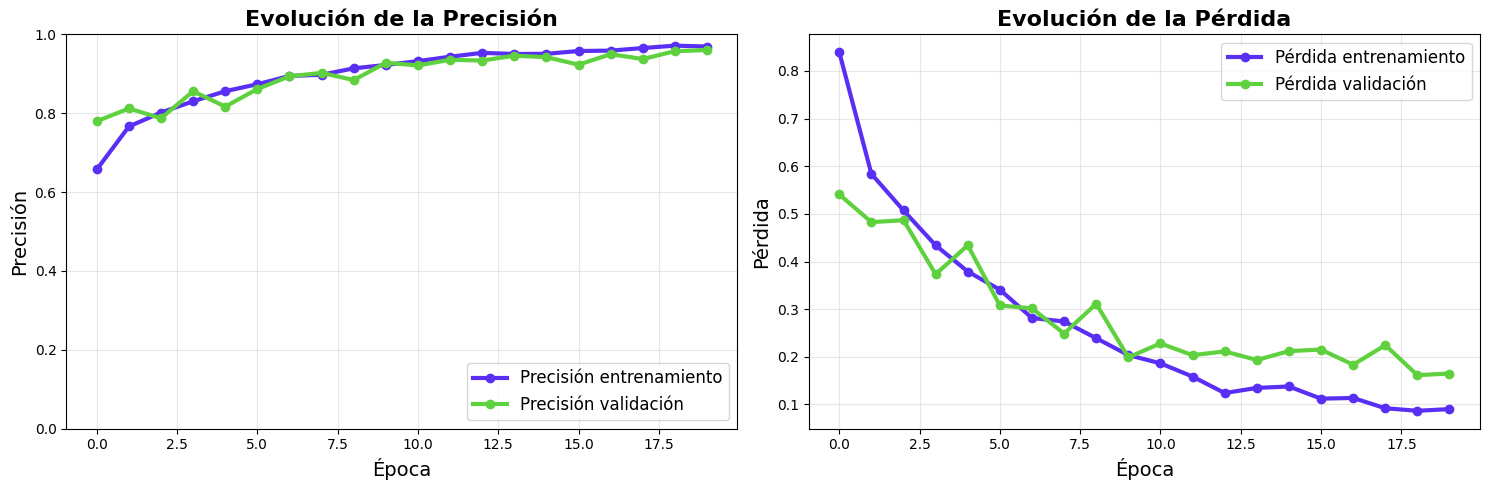


RESUMEN DEL ENTRENAMIENTO
Mejor época               : 20
Precisión en entrenamiento: 0.9691
Precisión en validación   : 0.9601
Épocas totales entrenadas : 20


In [12]:
def visualize_training_history(history):
    """
    Visualiza las curvas de precisión y pérdida del entrenamiento.
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Gráfica de precisión
    axes[0].plot(history['train_acc'], color='#5a2ff4', linestyle='-', marker='o',
                 label='Precisión entrenamiento', linewidth=3)
    axes[0].plot(history['val_acc'],   color='#60d13e', linestyle='-', marker='o',
                 label='Precisión validación',   linewidth=3)
    axes[0].set_xlabel('Época', fontsize=14)
    axes[0].set_ylabel('Precisión', fontsize=14)
    axes[0].set_title('Evolución de la Precisión', fontsize=16, fontweight='bold')
    axes[0].set_ylim([0, 1])
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(fontsize=12, loc='lower right')

    # Gráfica de pérdida
    axes[1].plot(history['train_loss'], color='#5a2ff4', linestyle='-', marker='o',
                 label='Pérdida entrenamiento', linewidth=3)
    axes[1].plot(history['val_loss'],   color='#60d13e', linestyle='-', marker='o',
                 label='Pérdida validación',   linewidth=3)
    axes[1].set_xlabel('Época', fontsize=14)
    axes[1].set_ylabel('Pérdida', fontsize=14)
    axes[1].set_title('Evolución de la Pérdida', fontsize=16, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(fontsize=12, loc='upper right')

    plt.tight_layout()
    plt.show()

    best_epoch = int(np.argmax(history['val_acc']))
    print("\n" + "=" * 60)
    print("RESUMEN DEL ENTRENAMIENTO")
    print("=" * 60)
    print(f"Mejor época               : {best_epoch + 1}")
    print(f"Precisión en entrenamiento: {history['train_acc'][best_epoch]:.4f}")
    print(f"Precisión en validación   : {history['val_acc'][best_epoch]:.4f}")
    print(f"Épocas totales entrenadas : {len(history['train_acc'])}")
    print("=" * 60)

visualize_training_history(history)

## 10. Evaluación del Modelo en el Conjunto de Prueba

In [13]:
print("Evaluando el modelo en el conjunto de prueba...")
print("=" * 60)

test_loss, test_acc = evaluate(model, test_loader, criterion, DEVICE)

print("RESULTADOS FINALES EN EL CONJUNTO DE PRUEBA")
print("=" * 60)
print(f"Pérdida  (Loss)    : {test_loss:.4f}")
print(f"Precisión (Accuracy): {test_acc:.4f} ({test_acc*100:.2f}%)")
print("=" * 60)

Evaluando el modelo en el conjunto de prueba...
RESULTADOS FINALES EN EL CONJUNTO DE PRUEBA
Pérdida  (Loss)    : 0.1469
Precisión (Accuracy): 0.9544 (95.44%)


## 11. Matriz de Confusión y Métricas Adicionales

Generando predicciones en el conjunto de prueba...


/Users/I508111/miniconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


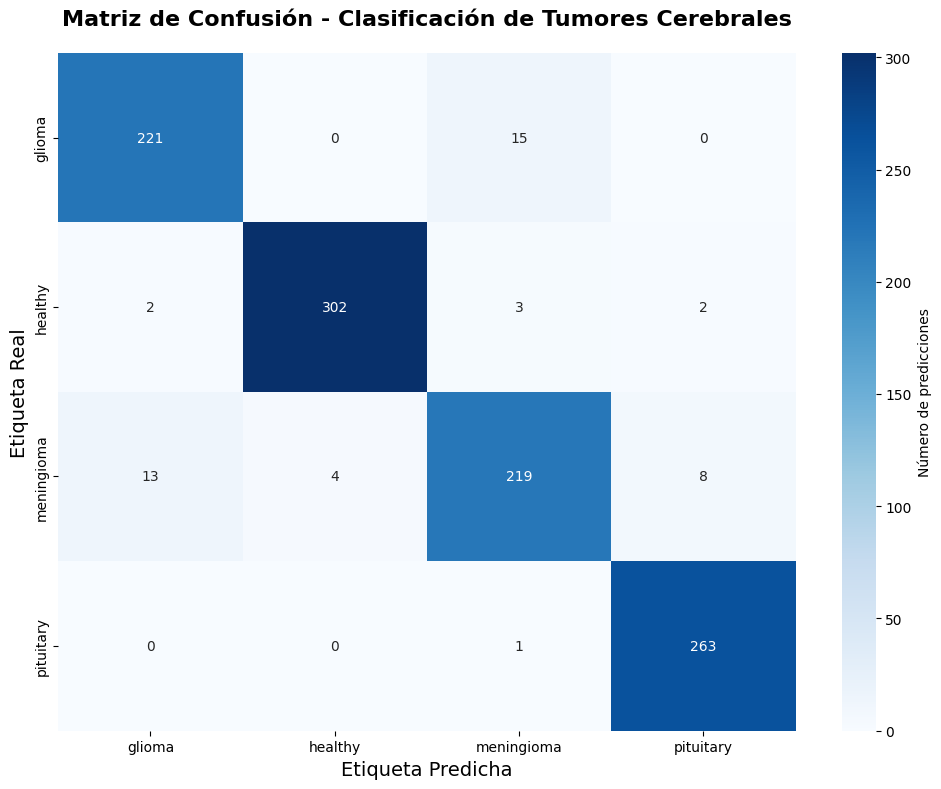


REPORTE DE CLASIFICACIÓN DETALLADO
              precision    recall  f1-score   support

      glioma     0.9364    0.9364    0.9364       236
     healthy     0.9869    0.9773    0.9821       309
  meningioma     0.9202    0.8975    0.9087       244
   pituitary     0.9634    0.9962    0.9795       264

    accuracy                         0.9544      1053
   macro avg     0.9517    0.9519    0.9517      1053
weighted avg     0.9542    0.9544    0.9542      1053



In [14]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

print("Generando predicciones en el conjunto de prueba...")

all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

y_pred = np.array(all_preds)
y_true = np.array(all_labels)

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Número de predicciones'})
plt.title('Matriz de Confusión - Clasificación de Tumores Cerebrales',
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Etiqueta Real', fontsize=14)
plt.xlabel('Etiqueta Predicha', fontsize=14)
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("REPORTE DE CLASIFICACIÓN DETALLADO")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))
print("=" * 60)

## 12. Guardar el Modelo Entrenado

In [15]:
model_path = 'brain_tumor_cnn_model_pytorch.pth'

torch.save({
    'model_state_dict': model.state_dict(),
    'num_classes': NUM_CLASSES,
    'class_names': class_names,
    'img_size': IMG_SIZE,
}, model_path)

print(f"Modelo guardado exitosamente en: {model_path}")
print(f"  Para cargar el modelo:")
print(f"    checkpoint = torch.load('{model_path}')")
print(f"    model = BrainTumorCNN(num_classes=checkpoint['num_classes'])")
print(f"    model.load_state_dict(checkpoint['model_state_dict'])")

Modelo guardado exitosamente en: brain_tumor_cnn_model_pytorch.pth
  Para cargar el modelo:
    checkpoint = torch.load('brain_tumor_cnn_model_pytorch.pth')
    model = BrainTumorCNN(num_classes=checkpoint['num_classes'])
    model.load_state_dict(checkpoint['model_state_dict'])


## 13. Conclusiones

### Resumen del Proyecto (versión PyTorch):

Este notebook implementó el mismo clasificador de tumores cerebrales que V0 pero usando **PyTorch**:

1. **Carga de datos**: `ImageFolder` + `random_split` + `DataLoader` (7,023 imágenes, 4 clases)
2. **Preprocesamiento**: `transforms.Resize` + `ToTensor` → píxeles en [0,1], división 70-15-15
3. **Arquitectura CNN**: Mismos 3 bloques convolucionales + BatchNorm + Dropout + capas densas
4. **Entrenamiento**: Loop explícito con `CrossEntropyLoss`, `Adam`, `ReduceLROnPlateau` y Early Stopping manual
5. **Evaluación**: Matriz de confusión y métricas detalladas por clase

### Diferencias clave TensorFlow/Keras vs PyTorch:

| Aspecto | TensorFlow/Keras (V0) | PyTorch (V1) |
|---|---|---|
| Carga de datos | `image_dataset_from_directory` | `ImageFolder` + `DataLoader` |
| Etiquetas | One-hot vectors | Índices enteros |
| Loss function | `categorical_crossentropy` | `CrossEntropyLoss` (con softmax) |
| Formato imagen | `[batch, H, W, C]` | `[batch, C, H, W]` |
| Loop de entrenamiento | `model.fit()` automático | Loop explícito con `backward()` |
| Early stopping | Callback de Keras | Lógica manual en el loop |
| Guardar modelo | `.h5` / `.keras` | `.pth` con `state_dict` |

### Próximos Pasos Posibles:

- **Data Augmentation**: `transforms.RandomHorizontalFlip`, `RandomRotation`, `ColorJitter`
- **Transfer Learning**: Usar `torchvision.models` (ResNet, EfficientNet, VGG) con `pretrained=True`
- **Mixed Precision**: `torch.cuda.amp` para acelerar entrenamiento en GPU
- **Ensemble**: Combinar múltiples modelos para mejorar precisión
- **Despliegue**: Exportar con `torch.jit.trace` o `torch.onnx.export`